Feature Engineering

In this phase, new features are created to improve model performance and better represent customer behavior

In [1]:
import pandas as pd
df=pd.read_csv("ecommerce_customer_churn_dataset.csv")
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [2]:
df.drop_duplicates(inplace=True)

In [3]:
num_cols = df.select_dtypes(include=['number']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [4]:
#Feature 1: Customer Engagement
#More activity = less churn
df["engagement_score"] = df["Login_Frequency"] * df["Session_Duration_Avg"]
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,engagement_score
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.000000,50.6,3.0,...,9.0,4.0,16.300000,20.8,1.000000,953.33,2278.0,0,Q1,383.6
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.300000,37.7,1.0,...,7.0,3.0,29.364466,23.3,3.000000,1067.47,3028.0,0,Q4,640.5
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.600000,70.9,1.0,...,4.0,1.0,29.364466,8.8,2.353874,1289.75,2317.0,0,Q4,248.0
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.800000,41.7,9.0,...,2.0,5.0,85.900000,31.0,3.000000,2340.92,2674.0,0,Q1,384.0
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.737811,19.1,9.0,...,1.0,11.0,83.000000,50.4,4.000000,3041.29,5354.0,0,Q4,1490.6


In [5]:
df[["engagement_score", "Churned"]].corr()

,engagement_score,Churned
engagement_score,1.000000,-0.185206
Churned,-0.185206,1.000000


Feature 2: Customer Value Category
👉 Business logic:
High value customers are important

In [6]:
df["customer_value"] = pd.cut(          #pd.cut: continuous value convet into categorized 
    df["Lifetime_Value"],
    bins=[0,2000,5000,10000],
    labels=["Low","Medium","High"]
)
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,engagement_score,customer_value
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.000000,50.6,3.0,...,4.0,16.300000,20.8,1.000000,953.33,2278.0,0,Q1,383.6,Low
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.300000,37.7,1.0,...,3.0,29.364466,23.3,3.000000,1067.47,3028.0,0,Q4,640.5,Low
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.600000,70.9,1.0,...,1.0,29.364466,8.8,2.353874,1289.75,2317.0,0,Q4,248.0,Low
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.800000,41.7,9.0,...,5.0,85.900000,31.0,3.000000,2340.92,2674.0,0,Q1,384.0,Medium
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.737811,19.1,9.0,...,11.0,83.000000,50.4,4.000000,3041.29,5354.0,0,Q4,1490.6,Medium


In [7]:
#Feature 3: Risk Category
#New customers → High churn risk 
df["risk_level"] = pd.cut(
    df["Membership_Years"],
    bins=[0,1,3,10],
    labels=["High Risk","Medium Risk","Low Risk"]
)
df.head()

# Insight:
# New customers (low membership years) show higher churn rates,
# indicating that early engagement is critical for retention.

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,engagement_score,customer_value,risk_level
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.000000,50.6,3.0,...,16.300000,20.8,1.000000,953.33,2278.0,0,Q1,383.6,Low,Medium Risk
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.300000,37.7,1.0,...,29.364466,23.3,3.000000,1067.47,3028.0,0,Q4,640.5,Low,Medium Risk
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.600000,70.9,1.0,...,29.364466,8.8,2.353874,1289.75,2317.0,0,Q4,248.0,Low,Medium Risk
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.800000,41.7,9.0,...,85.900000,31.0,3.000000,2340.92,2674.0,0,Q1,384.0,Medium,Medium Risk
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.737811,19.1,9.0,...,83.000000,50.4,4.000000,3041.29,5354.0,0,Q4,1490.6,Medium,Low Risk


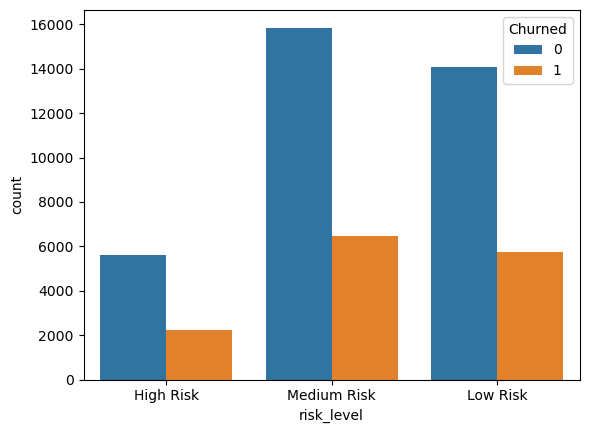

In [8]:
import seaborn as sns 
import matplotlib.pyplot as plt 
sns.countplot(x="risk_level", hue="Churned", data=df)
plt.show()

In [9]:
#Feature 4: Average Purchase Value
df["avg_purchase_value"] = df["Lifetime_Value"] / (df["Wishlist_Items"] + 1)  # +1 use for to avoide divid=sion error 
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,engagement_score,customer_value,risk_level,avg_purchase_value
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.000000,50.6,3.0,...,20.8,1.000000,953.33,2278.0,0,Q1,383.6,Low,Medium Risk,238.3325
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.300000,37.7,1.0,...,23.3,3.000000,1067.47,3028.0,0,Q4,640.5,Low,Medium Risk,533.7350
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.600000,70.9,1.0,...,8.8,2.353874,1289.75,2317.0,0,Q4,248.0,Low,Medium Risk,644.8750
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.800000,41.7,9.0,...,31.0,3.000000,2340.92,2674.0,0,Q1,384.0,Medium,Medium Risk,234.0920
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.737811,19.1,9.0,...,50.4,4.000000,3041.29,5354.0,0,Q4,1490.6,Medium,Low Risk,304.1290


In [10]:
#Encode new categorical features
df = pd.get_dummies(df, drop_first=True)   #why use: categorical data(low,medium etc) converted into numeric 

In [11]:
df.head()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,City_Toulouse,City_Vancouver,City_Yokohama,Signup_Quarter_Q2,Signup_Quarter_Q3,Signup_Quarter_Q4,customer_value_Medium,customer_value_High,risk_level_Medium Risk,risk_level_Low Risk
0,43.0,2.9,14.0,27.4,6.000000,50.6,3.0,9.0,94.72,34.0,...,False,False,False,False,False,False,False,False,True,False
1,36.0,1.6,15.0,42.7,10.300000,37.7,1.0,19.5,82.45,71.0,...,False,False,False,False,False,True,False,False,True,False
2,45.0,2.9,10.0,24.8,1.600000,70.9,1.0,9.1,165.52,11.0,...,False,True,False,False,False,True,False,False,True,False
3,56.0,2.6,10.0,38.4,14.800000,41.7,9.0,15.0,147.33,47.0,...,False,False,False,False,False,False,True,False,True,False
4,35.0,3.1,29.0,51.4,8.737811,19.1,9.0,32.5,141.30,73.0,...,False,False,False,False,False,True,True,False,False,True


In [12]:
print(df[['Session_Duration_Avg',
          
          'Product_Reviews_Written',
          'Credit_Balance']].describe())

print(df[['Session_Duration_Avg',
          'Product_Reviews_Written',
          'Credit_Balance']].head())

       Session_Duration_Avg  Product_Reviews_Written  Credit_Balance
count          50000.000000             50000.000000    50000.000000
mean              27.660754                 2.853312     1966.233258
std               10.494997                 2.245954     1155.729342
min                1.000000                 0.000000        0.000000
25%               20.200000                 1.000000     1164.000000
50%               27.660754                 2.853312     1966.233258
75%               34.000000                 4.000000     2664.000000
max               75.600000                21.000000     7197.000000
   Session_Duration_Avg  Product_Reviews_Written  Credit_Balance
0                  27.4                      4.0          2278.0
1                  42.7                      3.0          3028.0
2                  24.8                      1.0          2317.0
3                  38.4                      5.0          2674.0
4                  51.4                     11.0      

In [13]:
#save this into dataset 
df.to_csv("final_dataset.csv", index=False)

#####################################################################

In [ ]:
Feature Engineering Summary:

- Created engagement_score to measure customer activity.
- Created customer_value to categorize customers based on lifetime value.
- Created risk_level based on tenure.
- Created avg_purchase_value to understand spending behavior.

 These features help improve model performance.